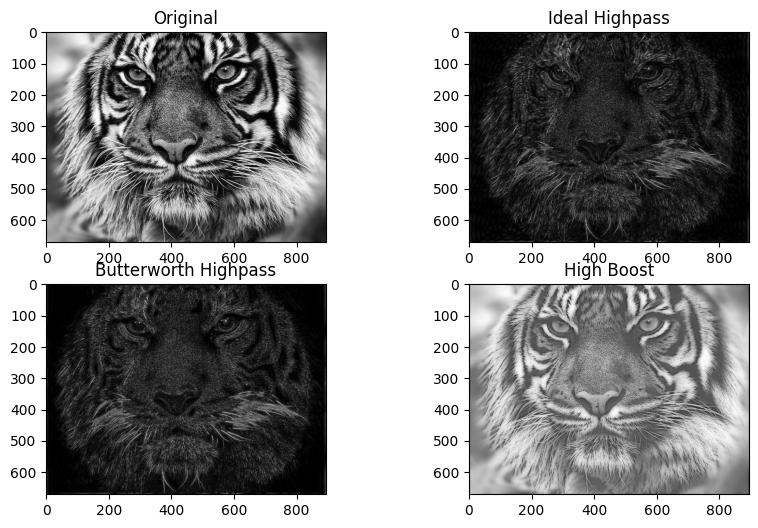

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Read grayscale image
img = cv2.imread("image.jpg",0)

# FFT
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)

rows, cols = img.shape
crow, ccol = rows//2 , cols//2

D0 = 30
n = 2

# Create filters
IHPF = np.ones((rows,cols))
BHPF = np.zeros((rows,cols))

for i in range(rows):
    for j in range(cols):

        D = np.sqrt((i-crow)**2 + (j-ccol)**2)

        # Ideal Highpass
        if D <= D0:
            IHPF[i,j] = 0

        # Butterworth Highpass
        if D == 0:
            BHPF[i,j] = 0
        else:
            BHPF[i,j] = 1/(1+(D0/D)**(2*n))

# Apply filters
ideal = fshift * IHPF
butter = fshift * BHPF

# Inverse FFT
ideal_img = np.abs(np.fft.ifft2(np.fft.ifftshift(ideal)))
butter_img = np.abs(np.fft.ifft2(np.fft.ifftshift(butter)))

# High-boost filtering
A = 1.5
high_boost = A*img - butter_img

# Display
plt.figure(figsize=(10,6))

plt.subplot(2,2,1)
plt.title("Original")
plt.imshow(img,cmap='gray')

plt.subplot(2,2,2)
plt.title("Ideal Highpass")
plt.imshow(ideal_img,cmap='gray')

plt.subplot(2,2,3)
plt.title("Butterworth Highpass")
plt.imshow(butter_img,cmap='gray')

plt.subplot(2,2,4)
plt.title("High Boost")
plt.imshow(high_boost,cmap='gray')

plt.show()